In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv("../data/devis_prepared.csv")
y=df["prix_final"]
X=df.drop(columns=["prix_final"])

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape , X_test.shape)

(800, 11) (200, 11)


In [5]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

model_lr=LinearRegression()
model_xg=XGBRegressor()
model_cat=CatBoostRegressor()

model_lr.fit(X_train,y_train)
model_xg.fit(X_train,y_train)
model_cat.fit(X_train,y_train)

Learning rate set to 0.039525
0:	learn: 2212.1510939	total: 146ms	remaining: 2m 26s
1:	learn: 2142.7368886	total: 149ms	remaining: 1m 14s
2:	learn: 2074.7615606	total: 151ms	remaining: 50s
3:	learn: 2013.3014630	total: 152ms	remaining: 37.9s
4:	learn: 1953.0940091	total: 154ms	remaining: 30.7s
5:	learn: 1895.0128438	total: 156ms	remaining: 25.8s
6:	learn: 1841.2841092	total: 158ms	remaining: 22.4s
7:	learn: 1787.8447718	total: 160ms	remaining: 19.8s
8:	learn: 1736.0752420	total: 162ms	remaining: 17.8s
9:	learn: 1689.1968693	total: 164ms	remaining: 16.2s
10:	learn: 1641.2359128	total: 165ms	remaining: 14.8s
11:	learn: 1597.0170469	total: 166ms	remaining: 13.6s
12:	learn: 1554.9094948	total: 167ms	remaining: 12.6s
13:	learn: 1514.1197203	total: 168ms	remaining: 11.8s
14:	learn: 1474.6092264	total: 169ms	remaining: 11.1s
15:	learn: 1434.5613674	total: 170ms	remaining: 10.4s
16:	learn: 1399.2468285	total: 170ms	remaining: 9.86s
17:	learn: 1362.9222966	total: 171ms	remaining: 9.35s
18:	lear

CatBoostRegressor(loss_function='RMSE')

In [6]:
#comparer les models

from sklearn.metrics import mean_absolute_error,r2_score
models={
    "Regression Lineaire":model_lr,
    "XGBoost":model_xg,
    "CatBoost":model_cat
}
for name,model in models.items():
    y_pred=model.predict(X_test)
    mae=mean_absolute_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    print(f"{name} -> MAE: {mae} , r2: {r2}")

Regression Lineaire -> MAE: 721.9819623126054 , r2: 0.8319329353904756
XGBoost -> MAE: 546.1015014648438 , r2: 0.8872776627540588
CatBoost -> MAE: 487.7398611977583 , r2: 0.9047545268821019


In [7]:
#sauvgarder le modele
import joblib
import os
os.makedirs("../models",exist_ok=True)
joblib.dump(model_cat,"../models/catboost_model.pkl")

['../models/catboost_model.pkl']

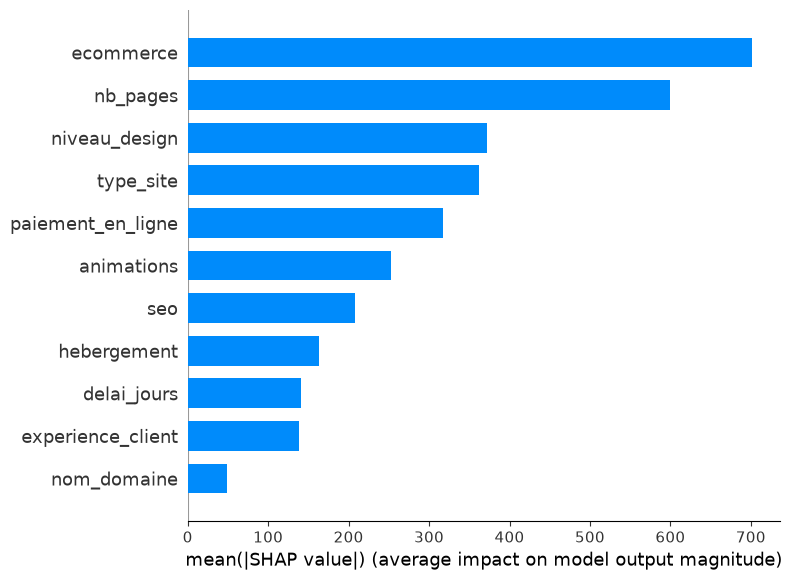

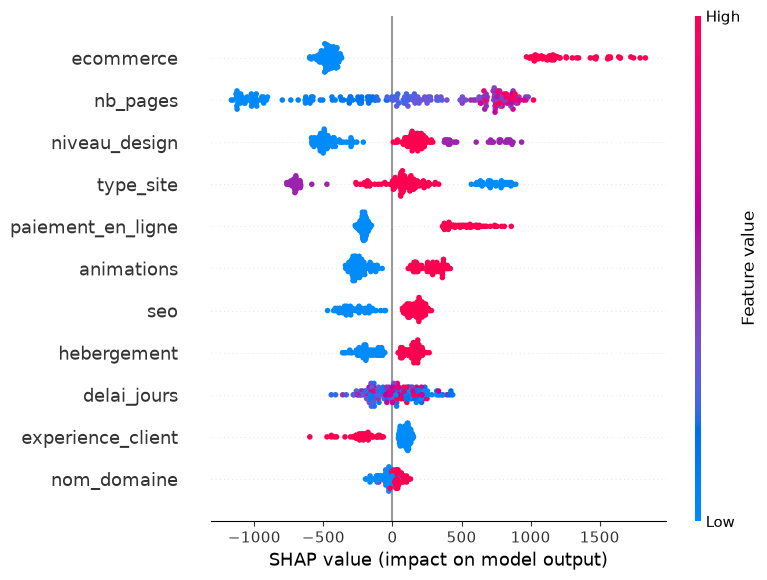

In [8]:
import shap
explainer=shap.Explainer(model_cat)
shap_values=explainer(X_test)
shap.summary_plot(shap_values,X_test,plot_type="bar")
shap.summary_plot(shap_values,X_test)